### mesop start kit
아래의 코드 py 파일로 작성
가상환경(파이썬 환경) 접속 > mesop 해당파일.py 실행

##### 실행결과 이미지

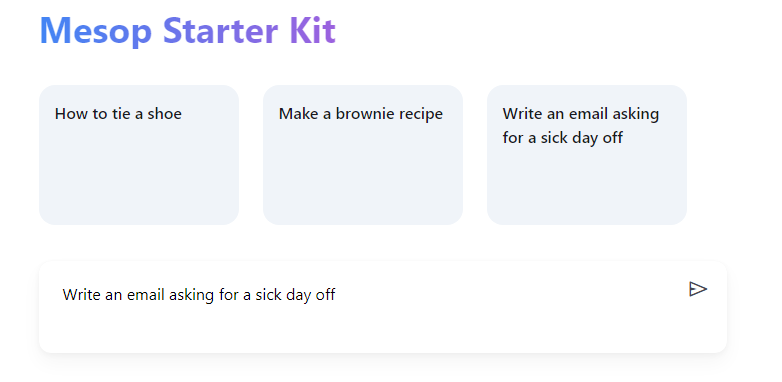

In [13]:
import time
import mesop as me

@me.stateclass
class State:
  input: str
  output: str
  in_progress: bool


@me.page(path="/starter_kit")
def page():
  with me.box(
    style=me.Style(
      background="#fff",
      min_height="calc(100% - 48px)",
      padding=me.Padding(bottom=16),
    )
  ):
    with me.box(
      style=me.Style(
        width="min(720px, 100%)",
        margin=me.Margin.symmetric(horizontal="auto"),
        padding=me.Padding.symmetric(
          horizontal=16,
        ),
      )
    ):
      header_text()
      example_row()
      chat_input()
      output()
  footer()


def header_text():
  with me.box(
    style=me.Style(
      padding=me.Padding(
        top=64,
        bottom=36,
      ),
    )
  ):
    me.text(
      "Mesop Starter Kit",
      style=me.Style(
        font_size=36,
        font_weight=700,
        background="linear-gradient(90deg, #4285F4, #AA5CDB, #DB4437) text",
        color="transparent",
      ),
    )


EXAMPLES = [
  "How to tie a shoe",
  "Make a brownie recipe",
  "Write an email asking for a sick day off",
]


def example_row():
  is_mobile = me.viewport_size().width < 640
  with me.box(
    style=me.Style(
      display="flex",
      flex_direction="column" if is_mobile else "row",
      gap=24,
      margin=me.Margin(bottom=36),
    )
  ):
    for example in EXAMPLES:
      example_box(example, is_mobile)


def example_box(example: str, is_mobile: bool):
  with me.box(
    style=me.Style(
      width="100%" if is_mobile else 200,
      height=140,
      background="#F0F4F9",
      padding=me.Padding.all(16),
      font_weight=500,
      line_height="1.5",
      border_radius=16,
      cursor="pointer",
    ),
    key=example,
    on_click=click_example_box,
  ):
    me.text(example)


def click_example_box(e: me.ClickEvent):
  state = me.state(State)
  state.input = e.key


def chat_input():
  state = me.state(State)
  with me.box(
    style=me.Style(
      padding=me.Padding.all(8),
      background="white",
      display="flex",
      width="100%",
      border=me.Border.all(
        me.BorderSide(width=0, style="solid", color="black")
      ),
      border_radius=12,
      box_shadow="0 10px 20px #0000000a, 0 2px 6px #0000000a, 0 0 1px #0000000a",
    )
  ):
    with me.box(
      style=me.Style(
        flex_grow=1,
      )
    ):
      me.native_textarea(
        value=state.input,
        autosize=True,
        min_rows=4,
        placeholder="Enter your prompt",
        style=me.Style(
          padding=me.Padding(top=16, left=16),
          background="white",
          outline="none",
          width="100%",
          overflow_y="auto",
          border=me.Border.all(
            me.BorderSide(style="none"),
          ),
        ),
        on_blur=textarea_on_blur,
      )
    with me.content_button(type="icon", on_click=click_send):
      me.icon("send")


def textarea_on_blur(e: me.InputBlurEvent):
  state = me.state(State)
  state.input = e.value


def click_send(e: me.ClickEvent):
  state = me.state(State)
  if not state.input:
    return
  state.in_progress = True
  input = state.input
  state.input = ""
  yield

  for chunk in call_api(input):
    state.output += chunk
    yield
  state.in_progress = False
  yield


def call_api(input):
  # Replace this with an actual API call
  time.sleep(0.5)
  yield "Example of streaming an output"
  time.sleep(1)
  yield "\n\nOutput: " + input


def output():
  state = me.state(State)
  if state.output or state.in_progress:
    with me.box(
      style=me.Style(
        background="#F0F4F9",
        padding=me.Padding.all(16),
        border_radius=16,
        margin=me.Margin(top=36),
      )
    ):
      if state.output:
        me.markdown(state.output)
      if state.in_progress:
        with me.box(style=me.Style(margin=me.Margin(top=16))):
          me.progress_spinner()


def footer():
  with me.box(
    style=me.Style(
      position="sticky",
      bottom=0,
      padding=me.Padding.symmetric(vertical=16, horizontal=16),
      width="100%",
      background="#F0F4F9",
      font_size=14,
    )
  ):
    me.html(
      "Made with <a href='https://google.github.io/mesop/'>Mesop</a>",
    )
